# Set 14 - NN2: Ziffernerkennung mit PyTorch auf der CPU

**Ziel:** Bilder als Tensoren verstehen, ein kleines Netz selbst definieren und einen vollständigen Trainingsablauf lesen.

Die handgeschriebenen Ziffern 0–9 sind echte 8×8-Graustufenbilder aus dem UCI-Digits-Datensatz, als kleine Auswahl bereits in scikit-learn enthalten. Sie sind bewusst kleiner als MNIST (28×28), damit die Beispiele schnell und offline funktionieren. Pixelwerte 0–16 werden fest durch 16 geteilt, nicht anhand des Tests skaliert.

Voraussetzung: NN1 / Set 13. PyTorch und torchvision ausschließlich mit der separaten CPU-Installation aus dem README installieren. In sämtlichen Beispielen ist `device="cpu"` fest vorgegeben.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn

kandidaten=[Path.cwd(),*Path.cwd().parents]
set_ordner=next((p for basis in kandidaten for p in (basis,basis/"set14-neuronale-netze-nn2")
                 if (p/"cv_tools.py").exists()),None)
if set_ordner is None:raise FileNotFoundError("Notebook innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:sys.path.insert(0,str(set_ordner))
from cv_tools import (cpu_setup,ziffern_split,loader,trainiere,auswerten,lernkurven,
                      bildgalerie,KleinesCNN,FrozenMobileNet,backbone_hash,
                      mobilenet_bilder,extrahiere_features)
device=cpu_setup()
print("PyTorch:",torch.__version__,"Gerät:",device,"CUDA-Build:",torch.version.cuda)
assert torch.version.cuda is None

PyTorch: 2.14.1+cpu Gerät: cpu CUDA-Build: None


Bilder: torch.Size([1797, 1, 8, 8]) Labels: torch.Size([1797])
Split: {'train': 1078, 'val': 359, 'test': 360}


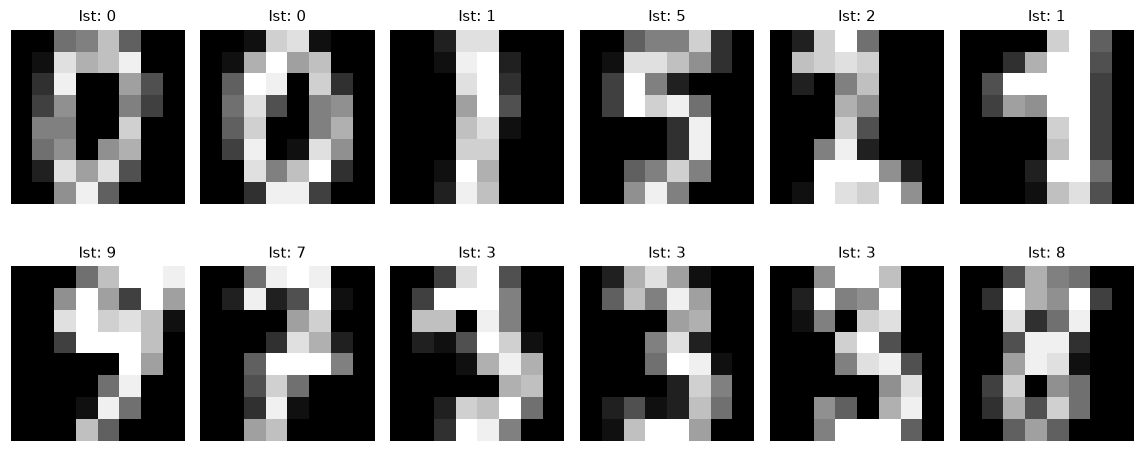

In [2]:
bilder,labels,split=ziffern_split()
print("Bilder:",bilder.shape,"Labels:",labels.shape)
print("Split:",{name:len(ids) for name,ids in split.items()})
bildgalerie(bilder[split["train"]],labels[split["train"]])

## 1. Ein Bild ist eine kleine Zahlentabelle

PyTorch verwendet bei Bildern die Reihenfolge **N × C × H × W**: Batchgröße, Kanäle, Höhe und Breite. Ein Graustufenbild hat einen Kanal, ein RGB-Bild drei. Der Pixelwert ist eine Intensität, keine schon bekannte Klasse.

Die Abbildung verbindet das sichtbare Bild mit den Zahlen. Das MLP flacht das Bild später auf 64 Eingabewerte ab; dabei ist die Nachbarschaft der Pixel nicht explizit als Struktur eingebaut.

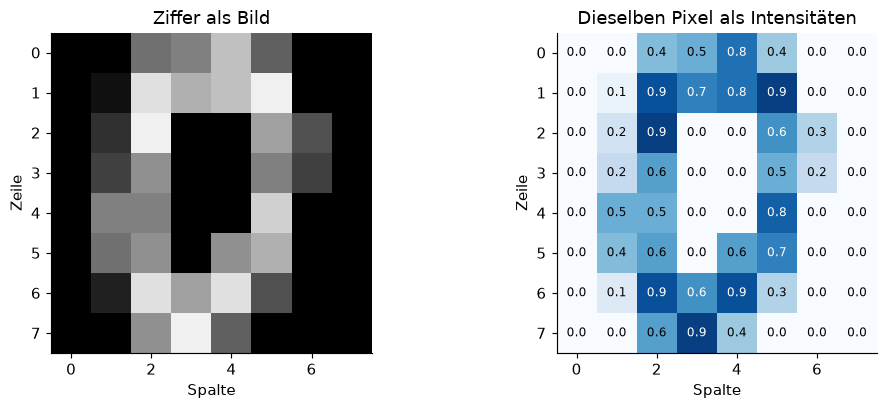

In [3]:
bild=bilder[split["train"][0],0]
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].imshow(bild,cmap="gray",vmin=0,vmax=1,interpolation="nearest")
axes[0].set(title="Ziffer als Bild",xlabel="Spalte",ylabel="Zeile"); axes[0].grid(False)
axes[1].imshow(bild,cmap="Blues",vmin=0,vmax=1)
for r in range(8):
    for c in range(8):axes[1].text(c,r,f"{bild[r,c]:.1f}",ha="center",va="center",fontsize=8,color="white" if bild[r,c]>0.6 else "black")
axes[1].set(title="Dieselben Pixel als Intensitäten",xlabel="Spalte",ylabel="Zeile"); axes[1].grid(False)
plt.tight_layout();plt.show()

## 2. Daten getrennt halten

Wir verwenden einen reproduzierbaren, stratifizierten Bildsplit: 60 % Training, 20 % Validierung und 20 % Test. Shuffle ist für Trainings-Minibatches zulässig; Validierung und Test werden nicht zum Gradientenlernen benutzt. Die Ziffernaufgabe ist keine Zeitreihe.

Das ist ein Bildsplit, kein Split nach schreibender Person. Da diese Auswahl keine Personen-IDs liefert, zeigt die Evaluation keine belegte Generalisierung auf völlig neue Handschriften.

In [4]:
train_loader=loader(bilder[split["train"]],labels[split["train"]],shuffle=True)
val_loader=loader(bilder[split["val"]],labels[split["val"]])
test_loader=loader(bilder[split["test"]],labels[split["test"]])
modell=nn.Sequential(nn.Flatten(),nn.Linear(64,48),nn.ReLU(),nn.Linear(48,10)).to(device)
print(modell)
print("Trainierbare Parameter:",sum(p.numel() for p in modell.parameters() if p.requires_grad))
xb,yb=next(iter(train_loader))
print("Batch:",xb.shape,"Labels:",yb.shape,"Logits:",modell(xb).shape)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=64, out_features=48, bias=True)
  (2): ReLU()
  (3): Linear(in_features=48, out_features=10, bias=True)
)
Trainierbare Parameter: 3610
Batch: torch.Size([64, 1, 8, 8]) Labels: torch.Size([64]) Logits: torch.Size([64, 10])


## 3. Logits, Loss und Gradient

Das Netz liefert zehn **Logits**, rohe Klassenscores. `CrossEntropyLoss` erwartet diese Logits und ganzzahlige Labels (`long`), deshalb gehört **kein Softmax vor die Loss**. Für die Anzeige von Wahrscheinlichkeiten verwenden wir Softmax später.

Eine Trainingsiteration lautet: Gradienten leeren → Vorwärtsrechnung → Loss → `backward()` → Optimizerschritt. Die kurze Funktion unten zeigt genau diese Reihenfolge; der gemeinsame Helfer wiederholt sie über Minibatches und Epochen.

In [5]:
def ein_trainingsschritt(netz,x,y,optimizer):
    netz.train()
    optimizer.zero_grad(set_to_none=True)
    logits=netz(x)
    loss=nn.CrossEntropyLoss()(logits,y)
    loss.backward()
    optimizer.step()
    return float(loss.detach())

# Separates Demonstrationsnetz; das eigentliche Training startet weiter unten neu.
demo=nn.Sequential(nn.Flatten(),nn.Linear(64,10))
optimizer=torch.optim.Adam(demo.parameters(),lr=0.005)
print("Loss eines Schritts:",ein_trainingsschritt(demo,xb,yb,optimizer))

Loss eines Schritts: 2.32694149017334


## 4. Lernen sichtbar machen

Wir trainieren 24 kurze Epochen. Pro Epoche wird die Validierung ohne Gradienten berechnet. Die Gewichte mit dem kleinsten Validierungs-Loss werden am Ende wiederhergestellt. Der Test entscheidet weder über die Epoche noch über die Einstellungen.

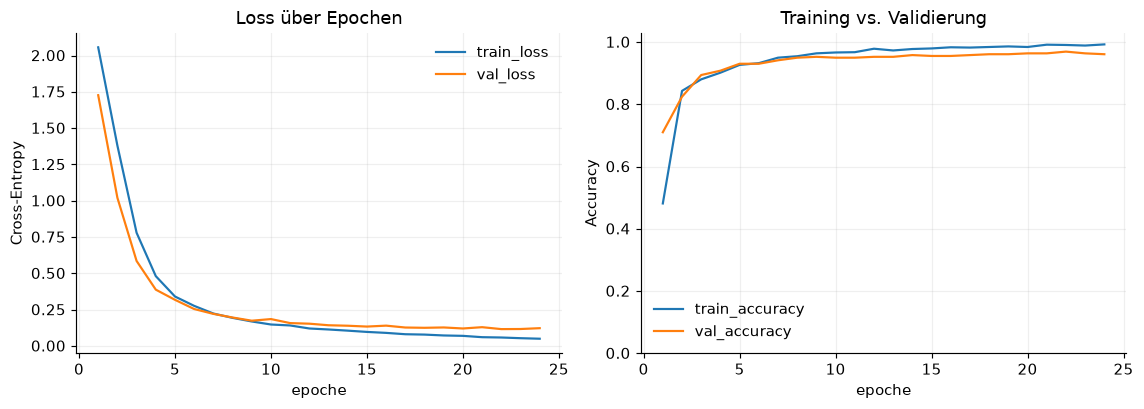

,train_loss,val_loss,train_accuracy,val_accuracy
epoche,,,,
20,0.069,0.120,0.984,0.964
21,0.060,0.129,0.992,0.964
22,0.058,0.116,0.991,0.969
23,0.053,0.117,0.989,0.964
24,0.050,0.122,0.993,0.961


In [6]:
cpu_setup(42)
modell=nn.Sequential(nn.Flatten(),nn.Linear(64,48),nn.ReLU(),nn.Linear(48,10))
historie=trainiere(modell,train_loader,val_loader,epochen=24,lr=0.005)
lernkurven(historie)
display(historie.tail().round(3))

## 5. Finaler Test: richtige und falsche Ziffern

Accuracy zeigt die Gesamttrefferquote. Die Confusion Matrix zeigt, welche Ziffern verwechselt werden. Einzelne Fehlerbilder helfen beim Interpretieren, ersetzen aber keine systematische Evaluation.

Test: {'loss': 0.1216076241599189, 'accuracy': 0.9722222089767456}


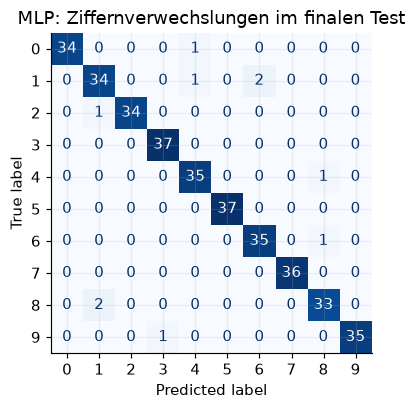

Fehlerbilder: 10


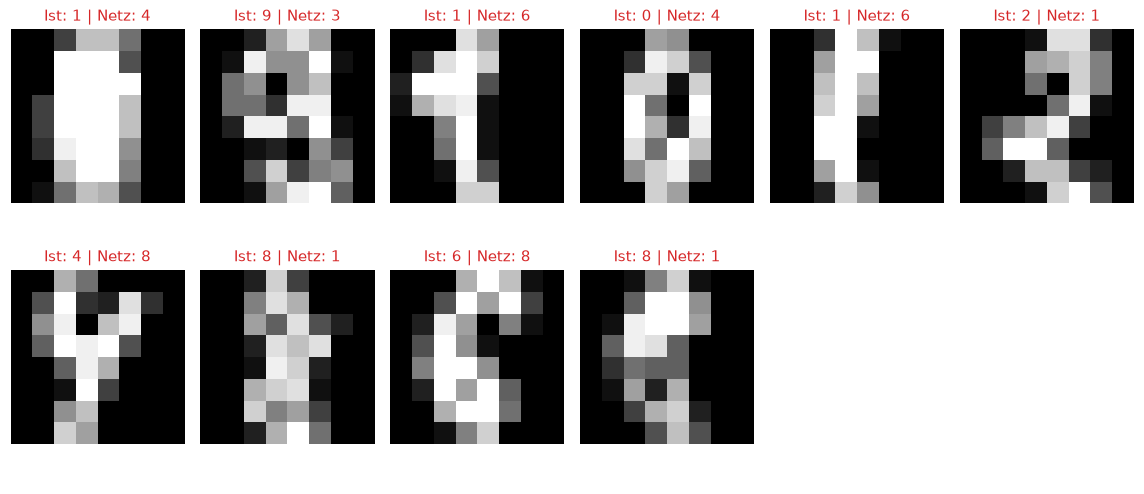

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
metriken,probs,y_test=auswerten(modell,test_loader)
print("Test:",metriken)
ConfusionMatrixDisplay.from_predictions(y_test.numpy(),probs.argmax(1).numpy(),cmap="Blues",colorbar=False)
plt.title("MLP: Ziffernverwechslungen im finalen Test");plt.tight_layout();plt.show()
fehler=(probs.argmax(1)!=y_test).nonzero().flatten()
print("Fehlerbilder:",len(fehler))
if len(fehler):bildgalerie(bilder[split["test"]][fehler],y_test[fehler],probs[fehler])

## 6. Interaktiv: Verschiebung und Rauschen

Wir verändern ein **Trainingsbild** und sehen, wie sich die Ausgabe des bereits trainierten Netzes ändert. Diese Ansichten sind anschauliche Robustheitsproben, keine neue Testmetrik. Auch eine hohe Softmax-Zahl kann bei ungewohnten Eingaben falsch sein; sie ist keine Garantie einer gut kalibrierten Sicherheit.

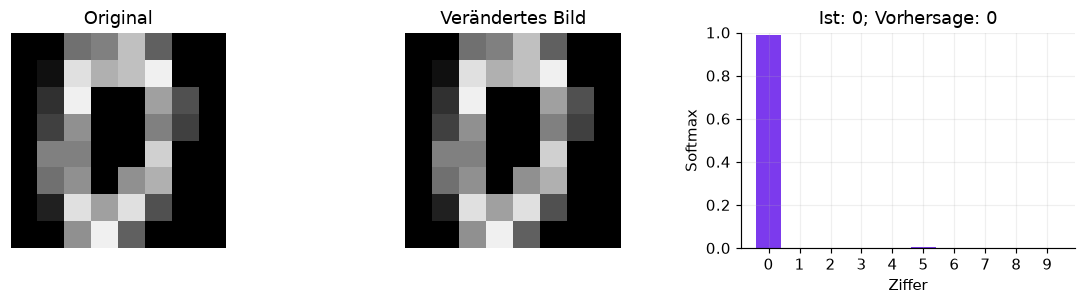

Output()

In [8]:
import ipywidgets as widgets
from torchvision.transforms import functional as TF

def experiment(index=0,verschiebung=0,rauschen=0.0):
    original=bilder[split["train"][index]]
    geaendert=TF.affine(original,angle=0,translate=[verschiebung,0],scale=1,shear=0,fill=0)
    noise=torch.randn(geaendert.shape,generator=torch.Generator().manual_seed(123))*rauschen
    geaendert=(geaendert+noise).clamp(0,1)
    modell.eval()
    with torch.inference_mode():p=modell(geaendert.unsqueeze(0)).softmax(1)[0]
    fig,axes=plt.subplots(1,3,figsize=(11,3))
    for ax,im,titel in [(axes[0],original[0],"Original"),(axes[1],geaendert[0],"Verändertes Bild")]:
        ax.imshow(im,cmap="gray",vmin=0,vmax=1);ax.set_title(titel);ax.axis("off")
    axes[2].bar(range(10),p.numpy(),color="#7c3aed")
    axes[2].set(title=f"Ist: {int(labels[split['train'][index]])}; Vorhersage: {int(p.argmax())}",xlabel="Ziffer",ylabel="Softmax",xticks=range(10),ylim=(0,1))
    plt.tight_layout();plt.show()
experiment()
index_regler=widgets.IntSlider(value=0,min=0,max=len(split["train"])-1,description="Bild",continuous_update=False)
shift_regler=widgets.IntSlider(value=0,min=-2,max=2,description="Shift [px]",continuous_update=False)
noise_regler=widgets.FloatSlider(value=0,min=0,max=0.4,step=0.05,description="Rauschen",continuous_update=False)
output=widgets.interactive_output(experiment,{"index":index_regler,"verschiebung":shift_regler,"rauschen":noise_regler})
display(widgets.VBox([index_regler,shift_regler,noise_regler]),output)

## Kleine Fragen
1. Was bedeuten die vier Dimensionen eines Bildbatches?
2. Warum benutzt die Loss Logits, der Wahrscheinlichkeitsplot aber Softmax?
3. Weshalb ist Pixelverschiebung für das MLP eine Herausforderung?

Datenquelle und Nutzung: `daten/README.md`.